
# Notebook 05 — Hybrid NLP + Structured Features

## Objective

Notebook 03 established the current champion:

> **Ridge + Word TF-IDF = 56.3653% MAPE**

Notebook 04 showed that structured features contain useful signal:

> **LightGBM + structured features = 58.2182% MAPE**

This notebook combines both sources of information.

### Hybrid experiments

1. **Word TF-IDF + Structured Features → Ridge**
2. **Word + Character TF-IDF + Structured Features → Ridge**
3. **Word TF-IDF + Structured Features → LightGBM**
4. **Word + Character TF-IDF + Structured Features → LightGBM**

The goal is to beat the **56.3653% MAPE** baseline while keeping the same validation split and Notebook 02 cleaning pipeline.

### Important

TF-IDF vocabulary is fitted only on the training split.

Numeric preprocessing statistics are also learned from the training split only.


## 0. Imports and configuration

In [1]:

import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 180)


CLEAN_DIR = "../dataset/cleaned"

TRAIN_FILE = os.path.join(
    CLEAN_DIR,
    "train_clean_experiment.csv"
)

TEST_FILE = os.path.join(
    CLEAN_DIR,
    "test_clean_experiment.csv"
)

ARTIFACT_DIR = "../artifacts/notebook_05"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

VALID_SIZE = 0.20
RANDOM_STATE = 42


WORD_NGRAM_RANGE = (1, 2)
WORD_MIN_DF = 2
WORD_MAX_DF = 0.98
WORD_MAX_FEATURES = 200_000

CHAR_NGRAM_RANGE = (3, 5)
CHAR_MIN_DF = 2
CHAR_MAX_DF = 0.995
CHAR_MAX_FEATURES = 150_000


RIDGE_ALPHA = 10.0

LGBM_N_ESTIMATORS = 800
LGBM_LEARNING_RATE = 0.03
LGBM_NUM_LEAVES = 31
LGBM_MIN_CHILD_SAMPLES = 30
LGBM_SUBSAMPLE = 0.85
LGBM_COLSAMPLE = 0.85
LGBM_REG_ALPHA = 0.1
LGBM_REG_LAMBDA = 1.0
LGBM_EARLY_STOPPING = 80


USE_LOG_TARGET = True
PREDICTION_MIN = 1e-6

RIDGE_WORD_BASELINE_MAPE = 56.3653

print("Configuration loaded.")


Configuration loaded.


## 1. Load cleaned data

In [2]:

train = pd.read_csv(TRAIN_FILE)
test = pd.read_csv(TEST_FILE)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head(3))


Train shape: (193693, 27)
Test shape : (50000, 26)


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH,DIM_1_CM,DIM_2_CM,DIM_3_CM,DIM_COUNT,DIM_PRODUCT_2D_CM2,DIM_VOLUME_CM3,HAS_DIMENSION_2D,HAS_DIMENSION_3D,TITLE_CHAR_COUNT,TITLE_WORD_COUNT,TITLE_DIGIT_COUNT,TITLE_EMPTY,BULLET_CHAR_COUNT,BULLET_WORD_COUNT,BULLET_DIGIT_COUNT,BULLET_EMPTY,DESC_CHAR_COUNT,DESC_WORD_COUNT,DESC_DIGIT_COUNT,DESC_EMPTY,HAS_MEASUREMENT_UNIT
0,667259,Work-Life Balance and Women's Entrepreneurship: An Exploration of Influencing Factors (Contribut...,NaN,NaN,6046,614.000000,15.7,21.0,8.509,0,329.7,2805.4173,0,0,123,14,0,0,0,0,0,1,0,0,0,1,0
1,2519657,YES2GOOD Back Case Cover for Oppo K3 Smoke Cover Protective Shockproof Translucent Hybrid Matte ...,[[Matte Translucent Case]: Made by high quality translucent matte non-glossy hard back and soft ...,YES2GOOD Matte Finish Shockproof Hard Back and Side Soft Smoke Back Case Cover can be easily ins...,12064,787.401574,1.0,3.0,17.800,0,3.0,53.4000,0,0,155,23,2,0,862,133,0,0,629,98,1,0,1
2,2169829,"Lettre ouverte du golfe de gascogne : Quelques propos insolites sur la société, la culture et la...",NaN,NaN,1,590.551180,6.0,11.0,2.500,0,66.0,165.0000,0,0,112,20,0,0,0,0,0,1,0,0,0,1,0


## 2. Validate cleaned data

In [3]:

REQUIRED_TRAIN = [
    "PRODUCT_ID",
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION",
    "PRODUCT_TYPE_ID",
    "PRODUCT_LENGTH"
]

REQUIRED_TEST = [
    "PRODUCT_ID",
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION",
    "PRODUCT_TYPE_ID"
]

for col in REQUIRED_TRAIN:
    assert col in train.columns, f"Missing train column: {col}"

for col in REQUIRED_TEST:
    assert col in test.columns, f"Missing test column: {col}"

assert "PRODUCT_LENGTH" not in test.columns
assert train["PRODUCT_ID"].is_unique
assert test["PRODUCT_ID"].is_unique
assert train["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train["PRODUCT_LENGTH"]).all()
assert (train["PRODUCT_LENGTH"] > 0).all()

print("Clean-data validation PASSED.")


Clean-data validation PASSED.


## 3. Build NLP text

In [4]:

TEXT_COLS = [
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION"
]

def build_text(df):
    text = (
        df["TITLE"].fillna("").astype(str) + " " +
        df["BULLET_POINTS"].fillna("").astype(str) + " " +
        df["DESCRIPTION"].fillna("").astype(str)
    )

    return (
        text
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

train["NLP_TEXT"] = build_text(train)
test["NLP_TEXT"] = build_text(test)

display(train[["TITLE", "NLP_TEXT"]].head(3))


,TITLE,NLP_TEXT
0,Work-Life Balance and Women's Entrepreneurship: An Exploration of Influencing Factors (Contribut...,Work-Life Balance and Women's Entrepreneurship: An Exploration of Influencing Factors (Contribut...
1,YES2GOOD Back Case Cover for Oppo K3 Smoke Cover Protective Shockproof Translucent Hybrid Matte ...,YES2GOOD Back Case Cover for Oppo K3 Smoke Cover Protective Shockproof Translucent Hybrid Matte ...
2,"Lettre ouverte du golfe de gascogne : Quelques propos insolites sur la société, la culture et la...","Lettre ouverte du golfe de gascogne : Quelques propos insolites sur la société, la culture et la..."


## 4. Fixed train / validation split

In [5]:

indices = np.arange(len(train))

train_idx, valid_idx = train_test_split(
    indices,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE
)

train_part = train.iloc[train_idx].copy()
valid_part = train.iloc[valid_idx].copy()

print("Training rows  :", len(train_part))
print("Validation rows:", len(valid_part))


Training rows  : 154954
Validation rows: 38739


## 5. Prepare target

In [6]:

y_raw = train["PRODUCT_LENGTH"].astype(np.float64).values

y_train_raw = y_raw[train_idx]
y_valid_raw = y_raw[valid_idx]

if USE_LOG_TARGET:
    y_train = np.log1p(y_train_raw)
    y_valid = np.log1p(y_valid_raw)
else:
    y_train = y_train_raw
    y_valid = y_valid_raw

print("Target mode:", "log1p" if USE_LOG_TARGET else "raw")


Target mode: log1p


## 6. Structured feature list

In [7]:

STRUCTURED_FEATURES = [
    "PRODUCT_TYPE_ID",

    "DIM_1_CM",
    "DIM_2_CM",
    "DIM_3_CM",
    "DIM_PRODUCT_2D_CM2",
    "DIM_VOLUME_CM3",

    "HAS_DIMENSION_2D",
    "HAS_DIMENSION_3D",

    "TITLE_CHAR_COUNT",
    "TITLE_WORD_COUNT",
    "TITLE_DIGIT_COUNT",
    "TITLE_EMPTY",

    "BULLET_CHAR_COUNT",
    "BULLET_WORD_COUNT",
    "BULLET_DIGIT_COUNT",
    "BULLET_EMPTY",

    "DESC_CHAR_COUNT",
    "DESC_WORD_COUNT",
    "DESC_DIGIT_COUNT",
    "DESC_EMPTY",

    "HAS_MEASUREMENT_UNIT"
]

missing = [
    c for c in STRUCTURED_FEATURES
    if c not in train.columns
]

assert not missing, f"Missing structured features: {missing}"

print("Structured features:", len(STRUCTURED_FEATURES))


Structured features: 21


## 7. Prepare structured features

In [8]:

X_struct_train = train_part[STRUCTURED_FEATURES].copy()
X_struct_valid = valid_part[STRUCTURED_FEATURES].copy()
X_struct_test = test[STRUCTURED_FEATURES].copy()

for df in [
    X_struct_train,
    X_struct_valid,
    X_struct_test
]:
    for col in STRUCTURED_FEATURES:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )

structured_medians = X_struct_train.median()

X_struct_train = X_struct_train.fillna(structured_medians)
X_struct_valid = X_struct_valid.fillna(structured_medians)
X_struct_test = X_struct_test.fillna(structured_medians)

print("Missing train:", X_struct_train.isna().sum().sum())
print("Missing valid:", X_struct_valid.isna().sum().sum())
print("Missing test :", X_struct_test.isna().sum().sum())


Missing train: 0
Missing valid: 0
Missing test : 0


## 8. Word TF-IDF

In [9]:

from sklearn.feature_extraction.text import TfidfVectorizer

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=WORD_NGRAM_RANGE,
    min_df=WORD_MIN_DF,
    max_df=WORD_MAX_DF,
    max_features=WORD_MAX_FEATURES,
    sublinear_tf=True,
    lowercase=True,
    strip_accents="unicode",
    dtype=np.float32
)

X_word_train = word_vectorizer.fit_transform(
    train_part["NLP_TEXT"]
)

X_word_valid = word_vectorizer.transform(
    valid_part["NLP_TEXT"]
)

X_word_test = word_vectorizer.transform(
    test["NLP_TEXT"]
)

print("Word TF-IDF:")
print("Train:", X_word_train.shape)
print("Valid:", X_word_valid.shape)
print("Test :", X_word_test.shape)


Word TF-IDF:
Train: (154954, 200000)
Valid: (38739, 200000)
Test : (50000, 200000)


## 9. Character TF-IDF

In [10]:

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=CHAR_NGRAM_RANGE,
    min_df=CHAR_MIN_DF,
    max_df=CHAR_MAX_DF,
    max_features=CHAR_MAX_FEATURES,
    sublinear_tf=True,
    dtype=np.float32
)

X_char_train = char_vectorizer.fit_transform(
    train_part["NLP_TEXT"]
)

X_char_valid = char_vectorizer.transform(
    valid_part["NLP_TEXT"]
)

X_char_test = char_vectorizer.transform(
    test["NLP_TEXT"]
)

print("Character TF-IDF:")
print("Train:", X_char_train.shape)
print("Valid:", X_char_valid.shape)
print("Test :", X_char_test.shape)


Character TF-IDF:
Train: (154954, 150000)
Valid: (38739, 150000)
Test : (50000, 150000)


## 10. Standardize structured features for Ridge

In [11]:

scaler = StandardScaler()

X_struct_train_scaled = scaler.fit_transform(
    X_struct_train
)

X_struct_valid_scaled = scaler.transform(
    X_struct_valid
)

X_struct_test_scaled = scaler.transform(
    X_struct_test
)

X_struct_train_scaled = sparse.csr_matrix(
    X_struct_train_scaled.astype(np.float32)
)

X_struct_valid_scaled = sparse.csr_matrix(
    X_struct_valid_scaled.astype(np.float32)
)

X_struct_test_scaled = sparse.csr_matrix(
    X_struct_test_scaled.astype(np.float32)
)

print("Structured sparse shape:")
print(X_struct_train_scaled.shape)


Structured sparse shape:
(154954, 21)


## 11. Hybrid Matrix A — Word TF-IDF + Structured Features

In [12]:

X_hybrid_word_train = sparse.hstack(
    [
        X_word_train,
        X_struct_train_scaled
    ],
    format="csr"
)

X_hybrid_word_valid = sparse.hstack(
    [
        X_word_valid,
        X_struct_valid_scaled
    ],
    format="csr"
)

X_hybrid_word_test = sparse.hstack(
    [
        X_word_test,
        X_struct_test_scaled
    ],
    format="csr"
)

print("Hybrid Word + Structured:")
print("Train:", X_hybrid_word_train.shape)
print("Valid:", X_hybrid_word_valid.shape)
print("Test :", X_hybrid_word_test.shape)


Hybrid Word + Structured:
Train: (154954, 200021)
Valid: (38739, 200021)
Test : (50000, 200021)


## 12. Ridge — Word TF-IDF + Structured

In [13]:

ridge_hybrid_word = Ridge(
    alpha=RIDGE_ALPHA,
    solver="lsqr"
)

ridge_hybrid_word.fit(
    X_hybrid_word_train,
    y_train
)

pred_hybrid_word_model = ridge_hybrid_word.predict(
    X_hybrid_word_valid
)

pred_hybrid_word = (
    np.expm1(pred_hybrid_word_model)
    if USE_LOG_TARGET
    else pred_hybrid_word_model
)

pred_hybrid_word = np.maximum(
    pred_hybrid_word,
    PREDICTION_MIN
)

print("Hybrid Word + Structured Ridge completed.")


Hybrid Word + Structured Ridge completed.


## 13. Hybrid Matrix B — Word + Character TF-IDF + Structured

In [14]:

X_hybrid_full_train = sparse.hstack(
    [
        X_word_train,
        X_char_train,
        X_struct_train_scaled
    ],
    format="csr"
)

X_hybrid_full_valid = sparse.hstack(
    [
        X_word_valid,
        X_char_valid,
        X_struct_valid_scaled
    ],
    format="csr"
)

X_hybrid_full_test = sparse.hstack(
    [
        X_word_test,
        X_char_test,
        X_struct_test_scaled
    ],
    format="csr"
)

print("Hybrid Word + Character + Structured:")
print("Train:", X_hybrid_full_train.shape)
print("Valid:", X_hybrid_full_valid.shape)
print("Test :", X_hybrid_full_test.shape)


Hybrid Word + Character + Structured:
Train: (154954, 350021)
Valid: (38739, 350021)
Test : (50000, 350021)


## 14. Ridge — Word + Character TF-IDF + Structured

In [15]:

ridge_hybrid_full = Ridge(
    alpha=RIDGE_ALPHA,
    solver="lsqr"
)

ridge_hybrid_full.fit(
    X_hybrid_full_train,
    y_train
)

pred_hybrid_full_model = ridge_hybrid_full.predict(
    X_hybrid_full_valid
)

pred_hybrid_full = (
    np.expm1(pred_hybrid_full_model)
    if USE_LOG_TARGET
    else pred_hybrid_full_model
)

pred_hybrid_full = np.maximum(
    pred_hybrid_full,
    PREDICTION_MIN
)

print("Hybrid full Ridge completed.")


Hybrid full Ridge completed.


## 15. MAPE evaluation

In [16]:

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    mask = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
        & (y_true != 0)
    )

    return np.mean(
        np.abs(
            (y_true[mask] - y_pred[mask])
            / y_true[mask]
        )
    ) * 100.0


def evaluate_model(name, y_true, y_pred):

    y_pred = np.maximum(
        np.asarray(y_pred, dtype=np.float64),
        PREDICTION_MIN
    )

    result = {
        "model": name,
        "MAPE": mape(y_true, y_pred),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    }

    print(f"\n{name}")
    print("-" * len(name))
    print(f"MAPE : {result['MAPE']:.4f}%")
    print(f"MAE  : {result['MAE']:.4f}")
    print(f"RMSE : {result['RMSE']:.4f}")

    return result


## 16. Evaluate Ridge hybrid models

In [17]:

ridge_hybrid_word_result = evaluate_model(
    "Ridge — Word TF-IDF + Structured",
    y_valid_raw,
    pred_hybrid_word
)

ridge_hybrid_full_result = evaluate_model(
    "Ridge — Word + Character TF-IDF + Structured",
    y_valid_raw,
    pred_hybrid_full
)



Ridge — Word TF-IDF + Structured
--------------------------------
MAPE : 51.3283%
MAE  : 412.1100
RMSE : 942.5927

Ridge — Word + Character TF-IDF + Structured
--------------------------------------------
MAPE : 50.1732%
MAE  : 400.2583
RMSE : 910.6505


## 17. LightGBM hybrid — dense structured + TF-IDF-derived predictions

In [18]:

# IMPORTANT:
# LightGBM is not given the full 350k+ sparse TF-IDF matrix here.
# Instead, we use the strong NLP Ridge predictions as an NLP signal
# and combine them with structured features.
#
# This gives the tree model a compact hybrid representation:
#
# structured features
#       +
# NLP Ridge prediction
#
# The NLP Ridge model is trained only on the training split.

nlp_signal_train_model = ridge_hybrid_word.predict(
    X_hybrid_word_train
)

nlp_signal_valid_model = ridge_hybrid_word.predict(
    X_hybrid_word_valid
)

if USE_LOG_TARGET:
    nlp_signal_train = np.expm1(nlp_signal_train_model)
    nlp_signal_valid = np.expm1(nlp_signal_valid_model)
else:
    nlp_signal_train = nlp_signal_train_model
    nlp_signal_valid = nlp_signal_valid_model

nlp_signal_train = np.maximum(
    nlp_signal_train,
    PREDICTION_MIN
)

nlp_signal_valid = np.maximum(
    nlp_signal_valid,
    PREDICTION_MIN
)

lgb_train = X_struct_train.copy()
lgb_valid = X_struct_valid.copy()

lgb_train["NLP_RIDGE_PRED"] = nlp_signal_train
lgb_valid["NLP_RIDGE_PRED"] = nlp_signal_valid

print("Compact hybrid LightGBM features:")
print(lgb_train.shape)

display(lgb_train.head(3))


Compact hybrid LightGBM features:
(154954, 22)


,PRODUCT_TYPE_ID,DIM_1_CM,DIM_2_CM,DIM_3_CM,DIM_PRODUCT_2D_CM2,DIM_VOLUME_CM3,HAS_DIMENSION_2D,HAS_DIMENSION_3D,TITLE_CHAR_COUNT,TITLE_WORD_COUNT,TITLE_DIGIT_COUNT,TITLE_EMPTY,BULLET_CHAR_COUNT,BULLET_WORD_COUNT,BULLET_DIGIT_COUNT,BULLET_EMPTY,DESC_CHAR_COUNT,DESC_WORD_COUNT,DESC_DIGIT_COUNT,DESC_EMPTY,HAS_MEASUREMENT_UNIT,NLP_RIDGE_PRED
70737,3224,24.0,7.000,11.000,168.000,1848.000,0,0,68,13,2,0,100,9,0,0,0,0,0,1,0,1349.843018
108751,2725,180.0,50.000,8.509,9000.000,76581.000,0,0,83,16,0,0,343,53,6,0,224,41,0,0,1,576.940735
155133,1358,23.0,2.286,2.000,52.578,105.156,0,0,69,8,3,0,658,91,3,0,101,17,0,0,1,533.023743


## 18. Train hybrid LightGBM

In [19]:

hybrid_lgbm = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=LGBM_N_ESTIMATORS,
    learning_rate=LGBM_LEARNING_RATE,
    num_leaves=LGBM_NUM_LEAVES,
    max_depth=-1,
    min_child_samples=LGBM_MIN_CHILD_SAMPLES,
    subsample=LGBM_SUBSAMPLE,
    colsample_bytree=LGBM_COLSAMPLE,
    reg_alpha=LGBM_REG_ALPHA,
    reg_lambda=LGBM_REG_LAMBDA,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

hybrid_lgbm.fit(
    lgb_train,
    y_train,
    eval_set=[(lgb_valid, y_valid)],
    callbacks=[
        lgb.early_stopping(
            LGBM_EARLY_STOPPING,
            verbose=False
        )
    ]
)

pred_hybrid_lgbm_model = hybrid_lgbm.predict(
    lgb_valid
)

pred_hybrid_lgbm = (
    np.expm1(pred_hybrid_lgbm_model)
    if USE_LOG_TARGET
    else pred_hybrid_lgbm_model
)

pred_hybrid_lgbm = np.maximum(
    pred_hybrid_lgbm,
    PREDICTION_MIN
)

hybrid_lgbm_result = evaluate_model(
    "LightGBM — Structured + NLP Ridge Signal",
    y_valid_raw,
    pred_hybrid_lgbm
)

print("Best iteration:", hybrid_lgbm.best_iteration_)



LightGBM — Structured + NLP Ridge Signal
----------------------------------------
MAPE : 49.3924%
MAE  : 376.1388
RMSE : 831.1129
Best iteration: 799


## 19. Final experiment comparison

In [20]:

results = pd.DataFrame([
    {
        "model": "Ridge + Word TF-IDF — Notebook 03",
        "MAPE": RIDGE_WORD_BASELINE_MAPE,
        "MAE": np.nan,
        "RMSE": np.nan
    },
    ridge_hybrid_word_result,
    ridge_hybrid_full_result,
    hybrid_lgbm_result
])

results = (
    results
    .sort_values("MAPE")
    .reset_index(drop=True)
)

display(results)


,model,MAPE,MAE,RMSE
0,LightGBM — Structured + NLP Ridge Signal,49.392446,376.138807,831.112888
1,Ridge — Word + Character TF-IDF + Structured,50.173182,400.258267,910.650463
2,Ridge — Word TF-IDF + Structured,51.328286,412.109955,942.592669
3,Ridge + Word TF-IDF — Notebook 03,56.365300,NaN,NaN


## 20. Select the best hybrid model

In [21]:

prediction_map = {
    "Ridge — Word TF-IDF + Structured": pred_hybrid_word,
    "Ridge — Word + Character TF-IDF + Structured": pred_hybrid_full,
    "LightGBM — Structured + NLP Ridge Signal": pred_hybrid_lgbm
}

non_baseline_results = results[
    results["model"] != "Ridge + Word TF-IDF — Notebook 03"
].copy()

best_hybrid_name = non_baseline_results.iloc[0]["model"]
best_hybrid_prediction = prediction_map[best_hybrid_name]

print("Best hybrid model:", best_hybrid_name)
print("MAPE:", non_baseline_results.iloc[0]["MAPE"])


Best hybrid model: LightGBM — Structured + NLP Ridge Signal
MAPE: 49.39244576513049


## 21. MAPE by target range

In [22]:

def mape_by_target_range(y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.maximum(
        np.asarray(y_pred),
        PREDICTION_MIN
    )

    ranges = [
        ("54-100", 54, 100),
        ("101-200", 101, 200),
        ("201-500", 201, 500),
        ("501-1000", 501, 1000),
        ("1001-2000", 1001, 2000),
        ("2001-5000", 2001, 5000),
        ("5001+", 5001, np.inf)
    ]

    rows = []

    for label, low, high in ranges:

        mask = (
            (y_true >= low)
            & (y_true <= high)
        )

        if mask.sum() == 0:
            continue

        rows.append({
            "range": label,
            "count": int(mask.sum()),
            "percentage": float(mask.mean() * 100),
            "MAPE": float(
                mape(
                    y_true[mask],
                    y_pred[mask]
                )
            )
        })

    return pd.DataFrame(rows)

display(
    mape_by_target_range(
        y_valid_raw,
        best_hybrid_prediction
    )
)


,range,count,percentage,MAPE
0,54-100,829,2.139962,536.026845
1,101-200,1281,3.306745,220.032598
2,201-500,6839,17.654044,60.191556
3,501-1000,19854,51.250678,21.164830
4,1001-2000,6992,18.048995,31.383071
5,2001-5000,2013,5.196314,44.499015
6,5001+,927,2.392937,49.188513


## 22. Worst validation errors

In [23]:

error_df = valid_part[
    [
        "PRODUCT_ID",
        "TITLE",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].copy()

error_df["prediction"] = best_hybrid_prediction

error_df["absolute_error"] = np.abs(
    error_df["PRODUCT_LENGTH"]
    - error_df["prediction"]
)

error_df["APE"] = (
    error_df["absolute_error"]
    / error_df["PRODUCT_LENGTH"]
) * 100

display(
    error_df
    .sort_values("APE", ascending=False)
    .head(50)
)


,PRODUCT_ID,TITLE,PRODUCT_TYPE_ID,PRODUCT_LENGTH,prediction,absolute_error,APE
47162,1441792,Buckle-Down DL-6FT-WDY287-W Pet Leash-Inside Out 6-Character Esxpression Blocks Purple/Multi Col...,7213,100.000000,4010.755885,3910.755885,3910.755885
35746,1589184,ASOKAM BAZAAR's Red Floral Print Poly Cotton Multicolor AC Dohar/Summer AC Blanket (Single Bed (...,1622,196.850393,7687.996260,7491.145866,3805.502104
111387,2061972,Nuha Rugs Shag Rug Beige and Ivory Color 5 cm Pile Height Modern Shaggy Carpet for Bedroom Home ...,1634,196.850393,6245.079221,6048.228828,3072.500248
74901,1706794,Kokka IRO Lei Nani Double Gauze Pink Fabric,8401,100.000000,3117.301709,3017.301709,3017.301709
72735,1566784,Island Batik Safari Tortoise Shell Grasshopper Fabric,6007,100.000000,2898.514591,2798.514591,2798.514591
108037,1058996,Blueberry Pet 5/8-inch by 5-Feet Classic Solid Small Basic Nylon Dog Leash Made For Last - Neon ...,7213,80.000000,2308.330311,2228.330311,2785.412889
127193,1309331,"Deco 79 98444 Rectangular Wooden Wall Panel, 27"" x 54"", Black/White",1555,100.000000,2883.672569,2783.672569,2783.672569
182343,1345007,Acerbis 2630630001,7754,100.000000,2855.953441,2755.953441,2755.953441
34628,2044746,Round Hanging Mirrors Wall Decor - Vanity Mounted Wall Mirror with Metal Frame for Contemporary ...,1588,100.000000,2842.618228,2742.618228,2742.618228
99113,1571783,Alpinestars GP PRO COMP SUIT BOOTCUT BLACK RED 52,12405,100.000000,2423.430445,2323.430445,2323.430445


## 23. Actual vs predicted

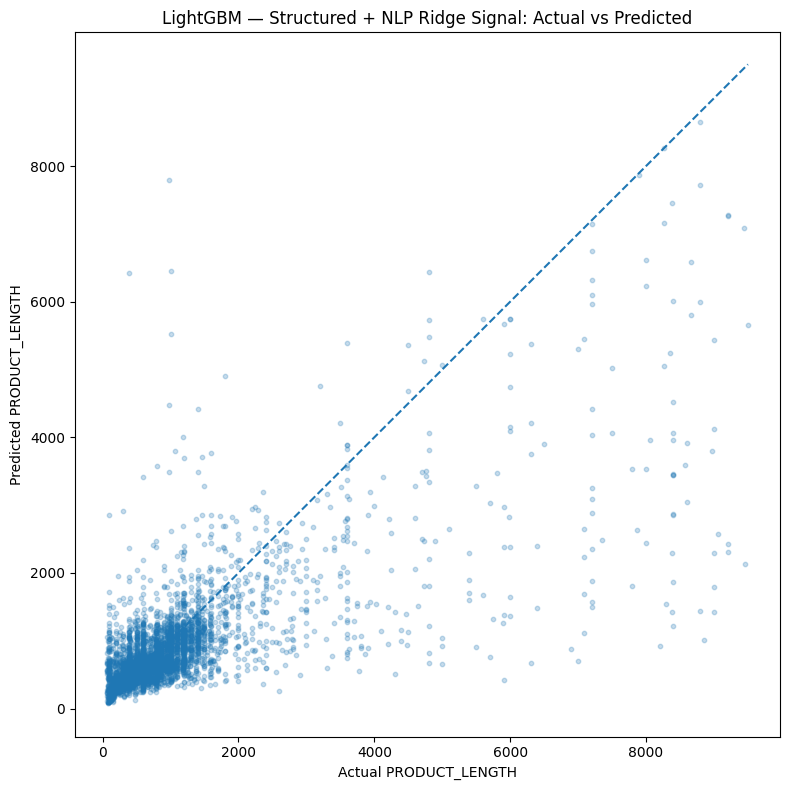

In [24]:

sample_size = min(
    5000,
    len(y_valid_raw)
)

rng = np.random.default_rng(
    RANDOM_STATE
)

sample_idx = rng.choice(
    len(y_valid_raw),
    size=sample_size,
    replace=False
)

fig, ax = plt.subplots(
    figsize=(8, 8)
)

ax.scatter(
    y_valid_raw[sample_idx],
    best_hybrid_prediction[sample_idx],
    alpha=0.25,
    s=10
)

low = min(
    y_valid_raw[sample_idx].min(),
    best_hybrid_prediction[sample_idx].min()
)

high = max(
    y_valid_raw[sample_idx].max(),
    best_hybrid_prediction[sample_idx].max()
)

ax.plot(
    [low, high],
    [low, high],
    linestyle="--"
)

ax.set_xlabel(
    "Actual PRODUCT_LENGTH"
)

ax.set_ylabel(
    "Predicted PRODUCT_LENGTH"
)

ax.set_title(
    f"{best_hybrid_name}: Actual vs Predicted"
)

plt.tight_layout()
plt.show()


## 24. Hybrid LightGBM feature importance

,feature,importance
21,NLP_RIDGE_PRED,3214
0,PRODUCT_TYPE_ID,2515
2,DIM_2_CM,1869
8,TITLE_CHAR_COUNT,1750
12,BULLET_CHAR_COUNT,1565
1,DIM_1_CM,1523
3,DIM_3_CM,1492
4,DIM_PRODUCT_2D_CM2,1196
13,BULLET_WORD_COUNT,1169
14,BULLET_DIGIT_COUNT,1159


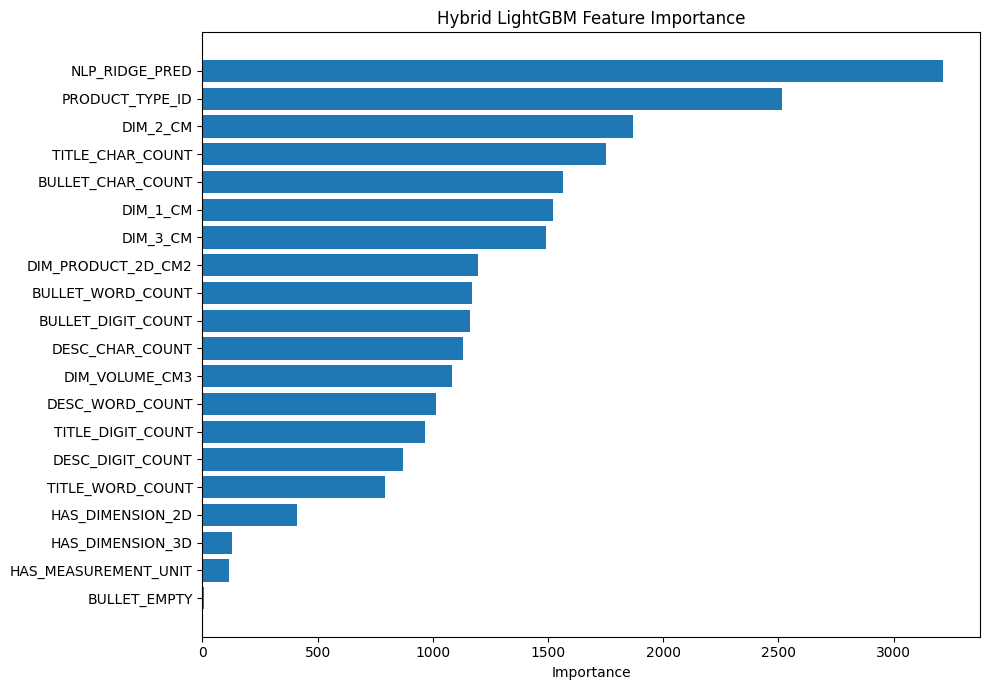

In [25]:

hybrid_lgbm_importance = pd.DataFrame({
    "feature": lgb_train.columns,
    "importance": hybrid_lgbm.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(hybrid_lgbm_importance)

top_n = min(
    20,
    len(hybrid_lgbm_importance)
)

plot_data = (
    hybrid_lgbm_importance
    .head(top_n)
    .sort_values("importance")
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    plot_data["feature"],
    plot_data["importance"]
)

ax.set_title(
    "Hybrid LightGBM Feature Importance"
)

ax.set_xlabel(
    "Importance"
)

plt.tight_layout()
plt.show()


## 25. Save validation predictions

In [26]:

validation_predictions = valid_part[
    [
        "PRODUCT_ID",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].copy()

validation_predictions["prediction"] = (
    best_hybrid_prediction
)

validation_predictions["APE"] = (
    np.abs(
        validation_predictions["PRODUCT_LENGTH"]
        - validation_predictions["prediction"]
    )
    / validation_predictions["PRODUCT_LENGTH"]
) * 100

prediction_file = os.path.join(
    ARTIFACT_DIR,
    "validation_predictions_best_hybrid.csv"
)

validation_predictions.to_csv(
    prediction_file,
    index=False
)

print("Saved:", prediction_file)


Saved: ../artifacts/notebook_05\validation_predictions_best_hybrid.csv


## 26. Save models and preprocessing artifacts

In [27]:

joblib.dump(
    word_vectorizer,
    os.path.join(
        ARTIFACT_DIR,
        "word_tfidf_vectorizer.joblib"
    )
)

joblib.dump(
    char_vectorizer,
    os.path.join(
        ARTIFACT_DIR,
        "char_tfidf_vectorizer.joblib"
    )
)

joblib.dump(
    scaler,
    os.path.join(
        ARTIFACT_DIR,
        "structured_scaler.joblib"
    )
)

joblib.dump(
    structured_medians,
    os.path.join(
        ARTIFACT_DIR,
        "structured_medians.joblib"
    )
)

joblib.dump(
    ridge_hybrid_word,
    os.path.join(
        ARTIFACT_DIR,
        "ridge_hybrid_word_structured.joblib"
    )
)

joblib.dump(
    ridge_hybrid_full,
    os.path.join(
        ARTIFACT_DIR,
        "ridge_hybrid_full.joblib"
    )
)

joblib.dump(
    hybrid_lgbm,
    os.path.join(
        ARTIFACT_DIR,
        "hybrid_lightgbm.joblib"
    )
)

print("Artifacts saved to:", ARTIFACT_DIR)


Artifacts saved to: ../artifacts/notebook_05


## 27. Save experiment configuration

In [28]:

config = {
    "train_file": TRAIN_FILE,
    "test_file": TEST_FILE,
    "validation_size": VALID_SIZE,
    "random_state": RANDOM_STATE,

    "structured_features": STRUCTURED_FEATURES,

    "word_tfidf": {
        "ngram_range": list(WORD_NGRAM_RANGE),
        "min_df": WORD_MIN_DF,
        "max_df": WORD_MAX_DF,
        "max_features": WORD_MAX_FEATURES
    },

    "char_tfidf": {
        "ngram_range": list(CHAR_NGRAM_RANGE),
        "min_df": CHAR_MIN_DF,
        "max_df": CHAR_MAX_DF,
        "max_features": CHAR_MAX_FEATURES
    },

    "ridge_alpha": RIDGE_ALPHA,

    "lightgbm": {
        "n_estimators": LGBM_N_ESTIMATORS,
        "learning_rate": LGBM_LEARNING_RATE,
        "num_leaves": LGBM_NUM_LEAVES,
        "min_child_samples": LGBM_MIN_CHILD_SAMPLES,
        "reg_alpha": LGBM_REG_ALPHA,
        "reg_lambda": LGBM_REG_LAMBDA
    },

    "baseline_mape": RIDGE_WORD_BASELINE_MAPE,
    "results": results.to_dict(
        orient="records"
    )
}

config_file = os.path.join(
    ARTIFACT_DIR,
    "experiment_config.json"
)

with open(
    config_file,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        config,
        f,
        indent=2
    )

print("Saved:", config_file)


Saved: ../artifacts/notebook_05\experiment_config.json



# Notebook 05 Complete

## Experiment progression

```text
Notebook 03
Ridge + Word TF-IDF
56.3653% MAPE
        ↓
Notebook 04
Structured Tree Models
        ↓
Notebook 05
Hybrid NLP + Structured
        ↓
Best model
```

The main benchmark remains:

> **56.3653% MAPE**

Do not modify Notebook 02 or the validation split while comparing these experiments.

### Next step

Run the notebook and send the final comparison table.

We will then decide whether the best model should be:

- the original Word TF-IDF Ridge,
- hybrid Ridge,
- or hybrid LightGBM.

If the hybrid model beats 56.3653%, it becomes the new project champion.
